In [1]:
%load_ext autoreload
%autoreload

import torch
import pandas as pd
import numpy as np
import os
import math
import yaml
from scipy import linalg
from scipy.stats import wasserstein_distance, linregress, t
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from itertools import combinations
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.distance_utils import *
from src.utils.analysis_utils import *


/gpfs3/well/papiez/users/hri611/python/data-centric-bias/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/gpfs3/well/papiez/users/hri611/python/data-centric-bias/env/lib/python3.11/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [ ]:
# =============================================================
# CONFIGURATION
# =============================================================

# Root directory of this repository
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))

# Where processed results are stored (download from data repository — see README)
RESULTS_DIR = os.path.join(BASE_DIR, 'processed_results')

# Where to save output figures
FIGS_DIR = os.path.join(BASE_DIR, 'final_figs')
os.makedirs(FIGS_DIR, exist_ok=True)

# Set to False to recompute distances from raw runs
SKIP_COMPUTE = True


In [3]:
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13
})


## Helper function for allocation performance bar plots

In [4]:
palette = sns.color_palette('colorblind', 10)

def plot_metric_bars(summary_perf_df, metric, proportions=[0, 50, 100],
                     ylim=[0, 1.0], save_fig=False, save_path='fig.pdf'):
    """Bar plot of mean performance at proportions 0, 50, 100 for each subgroup."""
    fig, ax = plt.subplots(figsize=(8, 5))
    labels = summary_perf_df['subgroup'].tolist()
    x = np.arange(len(labels))
    width = 0.25
    for i, prop in enumerate(proportions):
        means = summary_perf_df[f'{metric}_mean_at_{prop}'].values
        stds = summary_perf_df[f'{metric}_std_at_{prop}'].values
        ax.bar(x + i * width, means, width, yerr=stds, capsize=5,
               label=f'{prop}%', alpha=1, color=palette[2*i])
    ax.set_ylabel('Mean subgroup balanced accuracy' if metric == 'balanced_acc'
                  else f'Mean subgroup {metric}')
    ax.set_xlabel('')
    ax.set_xticks(x + width)
    ax.set_xticklabels(labels, rotation=0, ha='center')
    ax.legend(title='Allocation')
    plt.tight_layout()
    plt.ylim(ylim)
    if save_fig:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()


# CheXagent

## Compute distances

> **Note:** This section recomputes embedding distances from raw FM features. This is computationally expensive. **If you are using the pre-computed results (see README), skip to the _Visualise distances_ section below.**

In [ ]:
if not SKIP_COMPUTE:
    preds_metadata_df = pd.read_csv(os.path.join(BASE_DIR, 'data/MIMICFM/test_labels.csv'))
    
    features_list = [torch.load(path) for path in preds_metadata_df['embed_path']]
    features = torch.stack(features_list).float()
    
    # Determine number of PCA components for 70% variance
    results_df, sum_explained_variance = conduct_pca(features, preds_metadata_df, n_pc=50)
    cumulative_variance = np.cumsum(sum_explained_variance)
    n_components_70 = np.argmax(cumulative_variance >= 0.70) + 1
    avg_components = n_components_70
    print(f'Components for ≥70% variance: {n_components_70}')
    
    experiment_dict = {}
    seed = 42
    results_df, sum_explained_variance = conduct_pca(
        features, preds_metadata_df, n_pc=math.ceil(avg_components)
    )
    experiment_dict[seed] = results_df
    

In [ ]:
if not SKIP_COMPUTE:
    # Compute WD, MMD, FD, TVD
    attributes = [
        "ViewPosition_binary", "PatientOrientationCodeSequence_CodeMeaning_binary",
        "PerformedProcedureStepDescription_binary", "Support_Devices_binary",
        "Gender_binary", "Insurance_binary", "Language_binary",
        "Marital_Status_binary", "Race_cat_binary", "Age_binary", "Random_binary"
    ]
    pc_columns = ['PC' + str(n) for n in range(math.ceil(avg_components))]
    
    # Wasserstein Distance
    wd_results = {attr: {'WD_g0_vs_g1': []} for attr in attributes}
    for seed in experiment_dict:
        results_df = experiment_dict[seed]
        pos_df = results_df[results_df['Y'] == 1]
        neg_df = results_df[results_df['Y'] == 0]
        for pc in pc_columns:
            for attr in attributes:
                wd = np.mean([wasserstein_distance(pos_df.loc[pos_df[attr]==0, pc], pos_df.loc[pos_df[attr]==1, pc]),
                              wasserstein_distance(neg_df.loc[neg_df[attr]==0, pc], neg_df.loc[neg_df[attr]==1, pc])])
                wd_results[attr]['WD_g0_vs_g1'].append(wd)
    wd_df = pd.DataFrame(
        [{'WD_g0_vs_g1_mean': np.mean(v['WD_g0_vs_g1']), 'WD_g0_vs_g1_std': np.std(v['WD_g0_vs_g1'])}
         for v in wd_results.values()],
        index=[a.replace('_binary', '') for a in attributes]
    )
    
    # Fréchet Distance + TVD
    fd_results = {attr: {'FID_g0_vs_g1': [], 'TVD_g0_vs_g1': []} for attr in attributes}
    for seed in experiment_dict:
        results_df = experiment_dict[seed]
        feats = results_df[pc_columns].to_numpy()
        class_mask = results_df['Y'].values
        for attr in tqdm(attributes):
            gm = results_df[attr].values
            n0p = feats[(gm==0) & (class_mask==1)]; n1p = feats[(gm==1) & (class_mask==1)]
            n0n = feats[(gm==0) & (class_mask==0)]; n1n = feats[(gm==1) & (class_mask==0)]
            fd_results[attr]['FID_g0_vs_g1'].append(np.mean([compute_frechet_distance(n0n, n1n), compute_frechet_distance(n0p, n1p)]))
            fd_results[attr]['TVD_g0_vs_g1'].append(np.mean([compute_tvd(n0n, n1n), compute_tvd(n0p, n1p)]))
    fd_df = pd.DataFrame(
        [{'FID_g0_vs_g1_mean': np.mean(v['FID_g0_vs_g1']), 'FID_g0_vs_g1_std': np.std(v['FID_g0_vs_g1']),
          'TVD_g0_vs_g1_mean': np.mean(v['TVD_g0_vs_g1']), 'TVD_g0_vs_g1_std': np.std(v['TVD_g0_vs_g1'])}
         for v in fd_results.values()],
        index=[a.replace('_binary', '') for a in attributes]
    )
    
    df_all_metrics = wd_df.join(fd_df)
    df_all_metrics.rename(columns={'FID_g0_vs_g1_mean': 'FD_g0_vs_g1_mean',
                                    'FID_g0_vs_g1_std': 'FD_g0_vs_g1_std'}, inplace=True)
    out_path = os.path.join(RESULTS_DIR, 'fmmimic/pretrain_mean_distances_correct_pcs_stds_reduced_mmdfd.csv')
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    df_all_metrics.to_csv(out_path)
    print(f'Saved to {out_path}')
    

## Visualise distances

In [ ]:
df_all_metrics = pd.read_csv(os.path.join(RESULTS_DIR,
    'fmmimic/pretrain_mean_distances_correct_pcs_stds_reduced_mmdfd.csv'))
df_all_metrics.rename(columns={'Unnamed: 0': 'subgroup'}, inplace=True)
df_all_metrics.set_index('subgroup', inplace=True)
df_all_metrics = df_all_metrics.rename(index={'PerformedProcedureStepDescription': 'Procedure'})


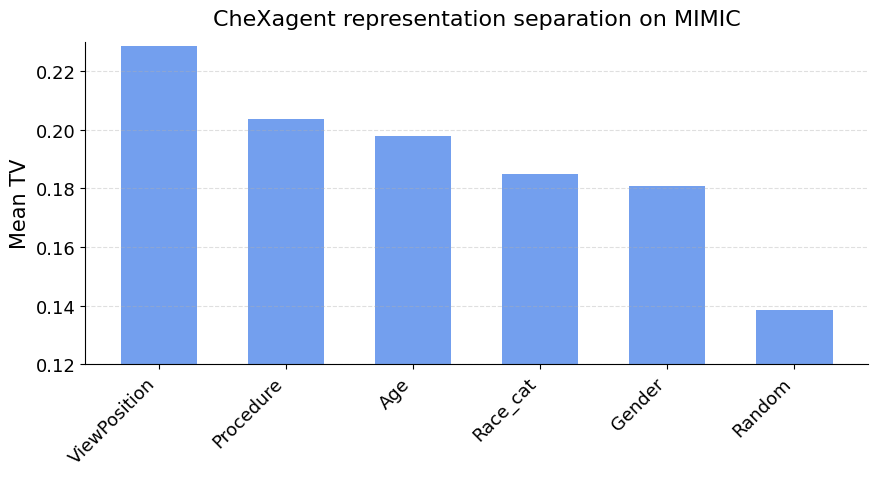

In [6]:
metric = 'TVD'
df_plot = df_all_metrics.sort_values(by=f'{metric}_g0_vs_g1_mean', ascending=False)
df_plot = df_plot[df_plot.index.isin(['Gender', 'Race_cat', 'Age', 'Procedure', 'ViewPosition', 'Random'])]
x = np.arange(len(df_plot.index))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x, df_plot[f'{metric}_g0_vs_g1_mean'], 0.6, alpha=0.9, color='cornflowerblue')
ax.set_xticks(x)
ax.set_xticklabels(df_plot.index, rotation=45, ha='right')
ax.set_ylabel('Mean TV')
ax.set_title('CheXagent representation separation on MIMIC', pad=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.ylim(0.12, 0.23)
plt.savefig(os.path.join(FIGS_DIR, 'fmmimic_TV.pdf'))
plt.show()


## Allocation sensitivity

In [7]:
label = 'Pleural_Effusion'
test_metadata_df = pd.read_csv(os.path.join(BASE_DIR, 'data/MIMICFM/test_labels.csv'))
test_metadata_df['id'] = test_metadata_df['dicom_id']

attributes = ['ViewPosition_binary', 'Gender_binary', 'Race_cat_binary', 'Age_binary',
              'Marital_Status_binary', 'Support_Devices_binary', 'Random_binary',
              'PerformedProcedureStepDescription_binary']

experiment_string = 'llrt_small_alloc'
required_lr = 0.001325
required_data_name = 'MIMICFM'

all_runs_df, summary_df = get_summary_df(
    experiment_string, test_metadata_df, required_lr, required_data_name, attributes
)

Skipping: logs/llrt_small_alloc_Gender_binary_60/runs/2025-09-25_05-56-37-812665/preds.csv
Skipping: logs/llrt_small_alloc_Race_cat_binary_60/runs/2025-09-25_05-46-48-751409/preds.csv
Skipping: logs/llrt_small_alloc_PerformedProcedureStepDescription_binary_60/runs/2025-09-25_05-42-54-436439/preds.csv


In [8]:
# Compute per-subgroup slopes
metrics = ['auc', 'balanced_acc', 'loss']
subgroups = all_runs_df['subgroup'].unique()
rows = []

for subgroup in subgroups:
    sg_df = all_runs_df[all_runs_df['subgroup'] == subgroup]
    x = sg_df['proportion'] / 100
    row = {'subgroup': subgroup}
    for metric in metrics:
        y_0 = sg_df[f'{metric}_group_0'].values[::-1]
        y_1 = sg_df[f'{metric}_group_1'].values
        res0 = linregress(x, y_0)
        res1 = linregress(x, y_1)
        row[f'{metric}_slope_group_0'] = res0.slope
        row[f'{metric}_slope_group_1'] = res1.slope
        row[f'{metric}_slope_mean'] = (res0.slope + res1.slope) / 2
        row[f'{metric}_slope_group_0_std'] = res0.stderr
        row[f'{metric}_slope_group_1_std'] = res1.stderr
        row[f'{metric}_slope_std'] = (res0.stderr + res1.stderr) / 2
    rows.append(row)

slopes_df = pd.DataFrame(rows)
slopes_df['subgroup'] = slopes_df['subgroup'].str.replace('_binary', '', regex=False)


In [9]:
# Summary performance at 0%, 50%, 100% allocation
rows = []
for subgroup in subgroups:
    sg_df = all_runs_df[all_runs_df['subgroup'] == subgroup]
    row = {'subgroup': subgroup}
    for metric in ['auc', 'balanced_acc', 'loss', 'acc']:
        for prop in [0, 50, 100]:
            prop_df = sg_df[sg_df['proportion'] == prop]
            g0 = prop_df[f'{metric}_group_0'].dropna().values
            g1 = prop_df[f'{metric}_group_1'].dropna().values
            row[f'{metric}_group_0_mean_at_{prop}'] = np.mean(g0) if len(g0) > 0 else np.nan
            row[f'{metric}_group_1_mean_at_{prop}'] = np.mean(g1) if len(g1) > 0 else np.nan
            row[f'{metric}_group_0_std_at_{prop}'] = (np.std(g0, ddof=1)/np.sqrt(3)) if len(g0) > 1 else np.nan
            row[f'{metric}_group_1_std_at_{prop}'] = (np.std(g1, ddof=1)/np.sqrt(3)) if len(g1) > 1 else np.nan
            both = np.concatenate([g0, g1])
            row[f'{metric}_mean_at_{prop}'] = np.mean(both) if len(both) > 0 else np.nan
            row[f'{metric}_std_at_{prop}'] = (row[f'{metric}_group_0_std_at_{prop}']
                                              + row[f'{metric}_group_1_std_at_{prop}']) / 2
    rows.append(row)

summary_perf_df = pd.DataFrame(rows)
summary_perf_df['subgroup'] = summary_perf_df['subgroup'].str.replace('_binary', '', regex=False)


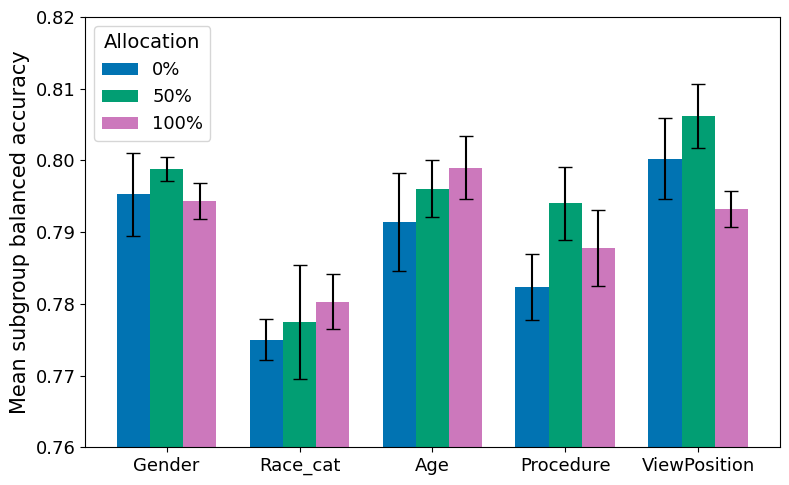

In [10]:
summary_perf_df['subgroup'] = summary_perf_df['subgroup'].replace(
    {'PerformedProcedureStepDescription': 'Procedure'}
)
order = ['Gender', 'Race_cat', 'Age', 'Procedure', 'ViewPosition']
subset_df = summary_perf_df[summary_perf_df['subgroup'].isin(order)].copy()
subset_df['subgroup'] = pd.Categorical(subset_df['subgroup'], categories=order, ordered=True)
subset_df = subset_df.sort_values('subgroup')

plot_metric_bars(subset_df, metric='balanced_acc', ylim=[0.76, 0.82],
                 save_fig=True, save_path=os.path.join(FIGS_DIR, 'fmmimic_allocation_gains.pdf'))


## Correlation: representation distance vs allocation sensitivity

In [11]:
emd_df = pd.read_csv(os.path.join(RESULTS_DIR,
    'fmmimic/pretrain_mean_distances_correct_pcs_stds_reduced_mmdfd.csv'))

emd_df['subgroup'] = emd_df['Unnamed: 0']
slopes_df = slopes_df.merge(emd_df, on='subgroup')
slopes_df = slopes_df.rename(columns={col: col.replace('FID', 'FD')
                                       for col in slopes_df.columns if 'FID' in col})
slopes_df = slopes_df.rename(columns={col: col.replace('TVD', 'TV')
                                       for col in slopes_df.columns if 'TVD' in col})


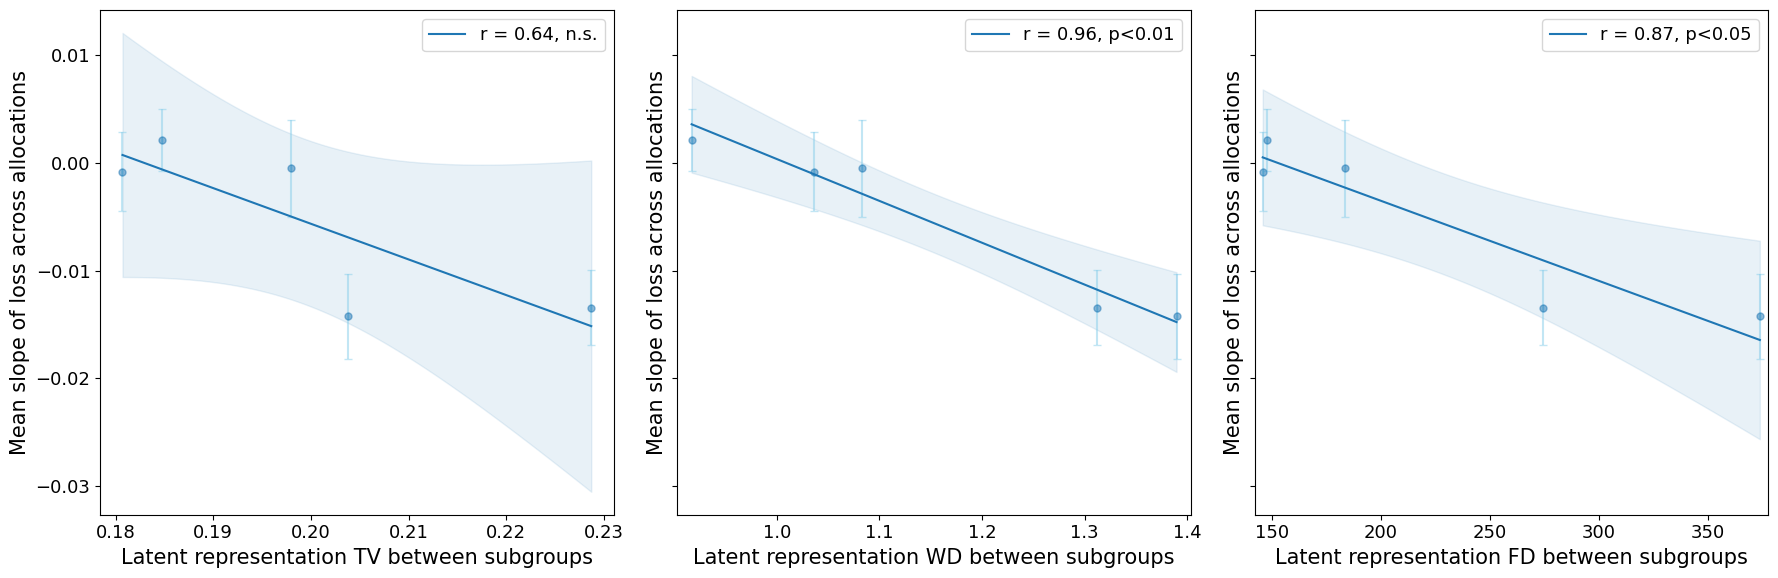

In [12]:
# Paper plot: distance vs slope regression
distance_metrics = ['TV', 'WD', 'FD']
metric = 'loss'

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for ax, dm in zip(axes, distance_metrics):
    x = slopes_df[f'{dm}_g0_vs_g1_mean'].values
    xerr = slopes_df[f'{dm}_g0_vs_g1_std'].values
    y = slopes_df[f'{metric}_slope_mean'].values
    yerr = slopes_df[f'{metric}_slope_std'].values

    ax.errorbar(x, y, xerr=xerr, yerr=yerr,
                fmt='o', alpha=0.5, ecolor='skyblue', capsize=3, markersize=5)

    slope, intercept, r_value, p_value, _ = linregress(x, y)
    x_fit = np.linspace(min(x), max(x), 200)
    y_fit = slope * x_fit + intercept
    p_text = 'p<0.01' if p_value < 0.01 else ('p<0.05' if p_value < 0.05 else 'n.s.')

    n = len(x); dof = n - 2
    tval = t.ppf(0.975, dof)
    residuals = y - (slope * x + intercept)
    s_err = np.sqrt(np.sum(residuals**2) / dof)
    conf = tval * s_err * np.sqrt(1/n + (x_fit - np.mean(x))**2 / np.sum((x - np.mean(x))**2))

    ax.plot(x_fit, y_fit, color='#1f77b4', label=f'r = {r_value**2:.2f}, {p_text}')
    ax.fill_between(x_fit, y_fit - conf, y_fit + conf, color='#1f77b4', alpha=0.1)
    ax.set_xlabel(f'Latent representation {dm} between subgroups')
    ax.set_ylabel(f'Mean slope of {metric} across allocations')
    ax.set_xlim(min(x) - 0.01*max(x), 1.01*max(x))
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'fmmimic_distances_slope.pdf'), bbox_inches='tight')
plt.show()


# RAD-DINO-MAIRA-2

## Compute distances

> **Note:** This section recomputes embedding distances from raw FM features. This is computationally expensive. **If you are using the pre-computed results (see README), skip to the _Visualise distances_ section below.**

In [13]:
if not SKIP_COMPUTE:
    preds_metadata_df = pd.read_csv(os.path.join(BASE_DIR, 'data/MIMICFM2_Small/test_labels.csv'))
    
    features_list = [torch.load(path) for path in preds_metadata_df['embed_path']]
    features = torch.stack(features_list).float()
    
    # Determine number of PCA components for 70% variance
    results_df, sum_explained_variance = conduct_pca(features, preds_metadata_df, n_pc=200)
    cumulative_variance = np.cumsum(sum_explained_variance)
    n_components_70 = np.argmax(cumulative_variance >= 0.70) + 1
    avg_components = n_components_70
    print(f'Components for ≥70% variance: {n_components_70}')
    
    experiment_dict = {}
    seed = 42
    results_df, sum_explained_variance = conduct_pca(
        features, preds_metadata_df, n_pc=math.ceil(avg_components)
    )
    experiment_dict[seed] = results_df
    

In [ ]:
if not SKIP_COMPUTE:
    # Compute WD, FD, TVD
    attributes = [
        "ViewPosition_binary", "PerformedProcedureStepDescription_binary",
        "Support_Devices_binary", "Gender_binary", "Insurance_binary",
        "Marital_Status_binary", "Race_cat_binary", "Age_binary", "Random_binary"
    ]
    pc_columns = ['PC' + str(n) for n in range(math.ceil(avg_components))]
    
    # Load raw features for TVD/FD (not reduced)
    features_list = [torch.load(path) for path in preds_metadata_df['embed_path']]
    features_np = torch.stack(features_list).float().cpu().numpy()
    
    fd_tvd_results = {attr: {'FID_g0_vs_g1': [], 'TVD_g0_vs_g1': []} for attr in attributes}
    for seed in experiment_dict:
        results_df = experiment_dict[seed]
        class_mask = results_df['Y'].values
        for attr in tqdm(attributes):
            gm = results_df[attr].values
            n0p = features_np[(gm==0) & (class_mask==1)]; n1p = features_np[(gm==1) & (class_mask==1)]
            n0n = features_np[(gm==0) & (class_mask==0)]; n1n = features_np[(gm==1) & (class_mask==0)]
            # Use PC-reduced for TVD
            rdf = results_df
            n0p_pc = rdf[(rdf[attr]==0) & (rdf['Y']==1)][pc_columns].to_numpy()
            n1p_pc = rdf[(rdf[attr]==1) & (rdf['Y']==1)][pc_columns].to_numpy()
            n0n_pc = rdf[(rdf[attr]==0) & (rdf['Y']==0)][pc_columns].to_numpy()
            n1n_pc = rdf[(rdf[attr]==1) & (rdf['Y']==0)][pc_columns].to_numpy()
            fd_tvd_results[attr]['FID_g0_vs_g1'].append(np.mean([compute_frechet_distance(n0n, n1n), compute_frechet_distance(n0p, n1p)]))
            fd_tvd_results[attr]['TVD_g0_vs_g1'].append(np.mean([compute_tvd(n0n_pc, n1n_pc), compute_tvd(n0p_pc, n1p_pc)]))
    
    # Wasserstein
    wd_results = {attr: {'WD_g0_vs_g1': []} for attr in attributes}
    for seed in experiment_dict:
        rdf = experiment_dict[seed]
        pos_df = rdf[rdf['Y']==1]; neg_df = rdf[rdf['Y']==0]
        for pc in pc_columns:
            for attr in attributes:
                wd = np.mean([wasserstein_distance(pos_df.loc[pos_df[attr]==0, pc], pos_df.loc[pos_df[attr]==1, pc]),
                              wasserstein_distance(neg_df.loc[neg_df[attr]==0, pc], neg_df.loc[neg_df[attr]==1, pc])])
                wd_results[attr]['WD_g0_vs_g1'].append(wd)
    
    index = [a.replace('_binary', '') for a in attributes]
    wd_df = pd.DataFrame(
        [{'WD_g0_vs_g1_mean': np.mean(v['WD_g0_vs_g1']), 'WD_g0_vs_g1_std': np.std(v['WD_g0_vs_g1'])}
         for v in wd_results.values()], index=index)
    fd_tvd_df = pd.DataFrame(
        [{'FD_g0_vs_g1_mean': np.mean(v['FID_g0_vs_g1']), 'FD_g0_vs_g1_std': np.std(v['FID_g0_vs_g1']),
          'TVD_g0_vs_g1_mean': np.mean(v['TVD_g0_vs_g1']), 'TVD_g0_vs_g1_std': np.std(v['TVD_g0_vs_g1'])}
         for v in fd_tvd_results.values()], index=index)
    
    df_all_metrics2 = wd_df.join(fd_tvd_df)
    out_path = os.path.join(RESULTS_DIR, 'fmmimic2/pretrain_mean_distances_correct_pcs_stds.csv')
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    df_all_metrics2.to_csv(out_path)
    print(f'Saved to {out_path}')
    

## Visualise distances

In [ ]:
df_all_metrics2 = pd.read_csv(os.path.join(RESULTS_DIR,
    'fmmimic2/pretrain_mean_distances_correct_pcs_stds.csv'))
df_all_metrics2.rename(columns={'Unnamed: 0': 'subgroup'}, inplace=True)
df_all_metrics2.set_index('subgroup', inplace=True)
df_all_metrics2 = df_all_metrics2.rename(index={'PerformedProcedureStepDescription': 'Procedure'})


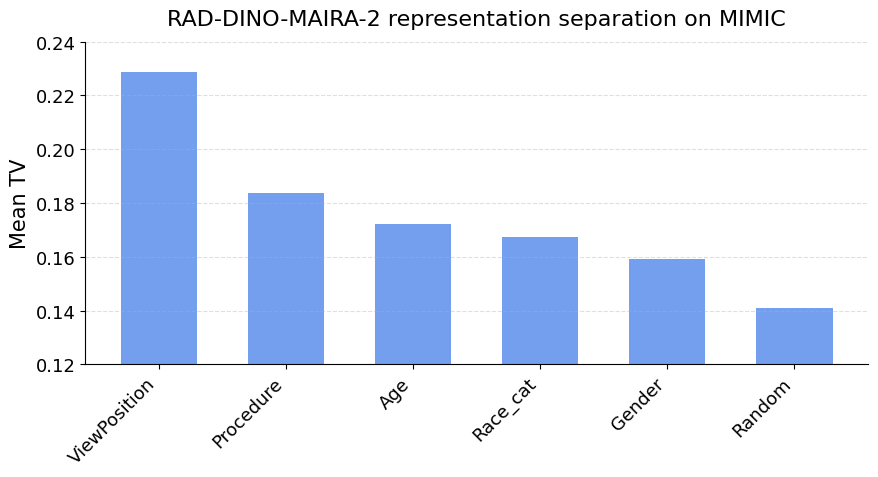

In [15]:
# Paper plot: TV representation separation
metric = 'TVD'
df_plot = df_all_metrics2.sort_values(by=f'{metric}_g0_vs_g1_mean', ascending=False)
df_plot = df_plot[df_plot.index.isin(['Gender', 'Race_cat', 'Age', 'Procedure', 'ViewPosition', 'Random'])]
x = np.arange(len(df_plot.index))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x, df_plot[f'{metric}_g0_vs_g1_mean'], 0.6, alpha=0.9, color='cornflowerblue')
ax.set_xticks(x)
ax.set_xticklabels(df_plot.index, rotation=45, ha='right')
ax.set_ylabel('Mean TV')
ax.set_title('RAD-DINO-MAIRA-2 representation separation on MIMIC', pad=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.ylim(0.12, 0.24)
plt.savefig(os.path.join(FIGS_DIR, 'fmmimic2_TV.pdf'))
plt.show()


## Allocation sensitivity

In [16]:
test_metadata_df2 = pd.read_csv(os.path.join(BASE_DIR, 'data/MIMICFM2_Small/test_labels.csv'))
test_metadata_df2['id'] = test_metadata_df2['dicom_id']

attributes2 = ['ViewPosition_binary', 'Gender_binary', 'Race_cat_binary', 'Age_binary',
               'PerformedProcedureStepDescription_binary']

experiment_string2 = 'llrt_small_alloc'
required_lr2 = 0.001326
required_data_name2 = ''  # FMMIMIC2 uses empty data name

all_runs_df2, summary_df2 = get_summary_df(
    experiment_string2, test_metadata_df2, required_lr2, required_data_name2, attributes2
)


Skipping: logs/llrt_small_alloc_ViewPosition_binary_50/runs/2025-11-23_14-46-02-089588/preds.csv
Skipping: logs/llrt_small_alloc_Gender_binary_70/runs/2025-11-23_14-49-23-812389/preds.csv
Skipping: logs/llrt_small_alloc_Race_cat_binary_50/runs/2025-11-23_14-43-39-600088/preds.csv
Skipping: logs/llrt_small_alloc_Race_cat_binary_50/runs/2025-11-23_21-19-34-815545/preds.csv
Skipping: logs/llrt_small_alloc_Age_binary_50/runs/2025-11-23_21-13-27-216026/preds.csv
Skipping: logs/llrt_small_alloc_Age_binary_60/runs/2025-11-23_14-47-51-866529/preds.csv
Skipping: logs/llrt_small_alloc_PerformedProcedureStepDescription_binary_60/runs/2025-11-23_14-44-31-359715/preds.csv


In [17]:
metrics = ['auc', 'balanced_acc', 'acc', 'loss']
subgroups2 = all_runs_df2['subgroup'].unique()
filtered_df2 = all_runs_df2.copy()

slopes_df2 = get_slopes_df(filtered_df2, metrics, subgroups2)

emd_df2 = pd.read_csv(os.path.join(RESULTS_DIR,
    'fmmimic2/pretrain_mean_distances_correct_pcs_stds.csv'))
emd_df2['subgroup'] = emd_df2['Unnamed: 0']

slopes_df2 = slopes_df2.merge(emd_df2, on='subgroup')
slopes_df2 = slopes_df2.rename(columns={col: col.replace('FID', 'FD')
                                         for col in slopes_df2.columns if 'FID' in col})
slopes_df2 = slopes_df2.rename(columns={col: col.replace('TVD', 'TV')
                                         for col in slopes_df2.columns if 'TVD' in col})


In [18]:
# Summary performance at 0%, 50%, 100%
rows = []
for subgroup in subgroups2:
    sg_df = all_runs_df2[all_runs_df2['subgroup'] == subgroup]
    row = {'subgroup': subgroup}
    for metric in ['auc', 'balanced_acc', 'loss', 'acc']:
        for prop in [0, 50, 100]:
            prop_df = sg_df[sg_df['proportion'] == prop]
            g0 = prop_df[f'{metric}_group_0'].dropna().values
            g1 = prop_df[f'{metric}_group_1'].dropna().values
            row[f'{metric}_group_0_mean_at_{prop}'] = np.mean(g0) if len(g0) > 0 else np.nan
            row[f'{metric}_group_1_mean_at_{prop}'] = np.mean(g1) if len(g1) > 0 else np.nan
            row[f'{metric}_group_0_std_at_{prop}'] = (np.std(g0, ddof=1)/np.sqrt(3)) if len(g0) > 1 else np.nan
            row[f'{metric}_group_1_std_at_{prop}'] = (np.std(g1, ddof=1)/np.sqrt(3)) if len(g1) > 1 else np.nan
            both = np.concatenate([g0, g1])
            row[f'{metric}_mean_at_{prop}'] = np.mean(both) if len(both) > 0 else np.nan
            row[f'{metric}_std_at_{prop}'] = (row[f'{metric}_group_0_std_at_{prop}']
                                              + row[f'{metric}_group_1_std_at_{prop}']) / 2
    rows.append(row)

summary_perf_df2 = pd.DataFrame(rows)
summary_perf_df2['subgroup'] = summary_perf_df2['subgroup'].str.replace('_binary', '', regex=False)


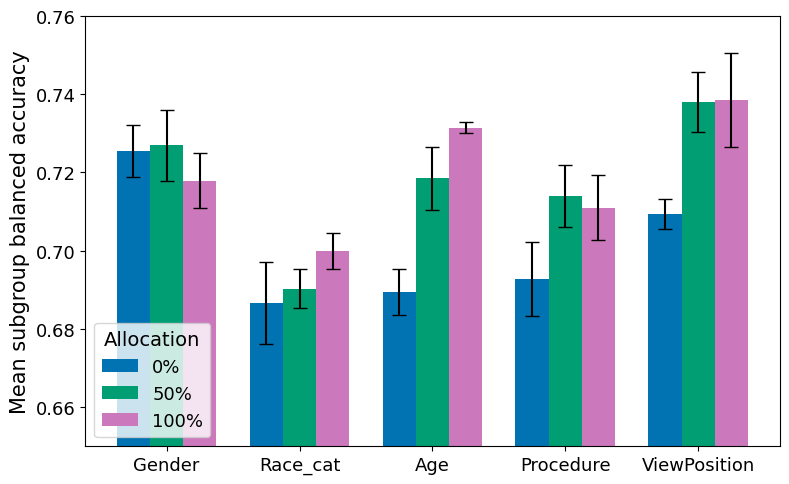

In [19]:
# Paper plot: allocation gains per subgroup
summary_perf_df2['subgroup'] = summary_perf_df2['subgroup'].replace(
    {'PerformedProcedureStepDescription': 'Procedure'}
)
order = ['Gender', 'Race_cat', 'Age', 'Procedure', 'ViewPosition']
subset_df2 = summary_perf_df2[summary_perf_df2['subgroup'].isin(order)].copy()
subset_df2['subgroup'] = pd.Categorical(subset_df2['subgroup'], categories=order, ordered=True)
subset_df2 = subset_df2.sort_values('subgroup')

plot_metric_bars(subset_df2, metric='balanced_acc', ylim=[0.65, 0.76],
                 save_fig=True, save_path=os.path.join(FIGS_DIR, 'fmmimic2_allocation_gains.pdf'))


## Correlation: representation distance vs allocation sensitivity

0.12155188377261124
0.04859542547431691
0.06165756185782738


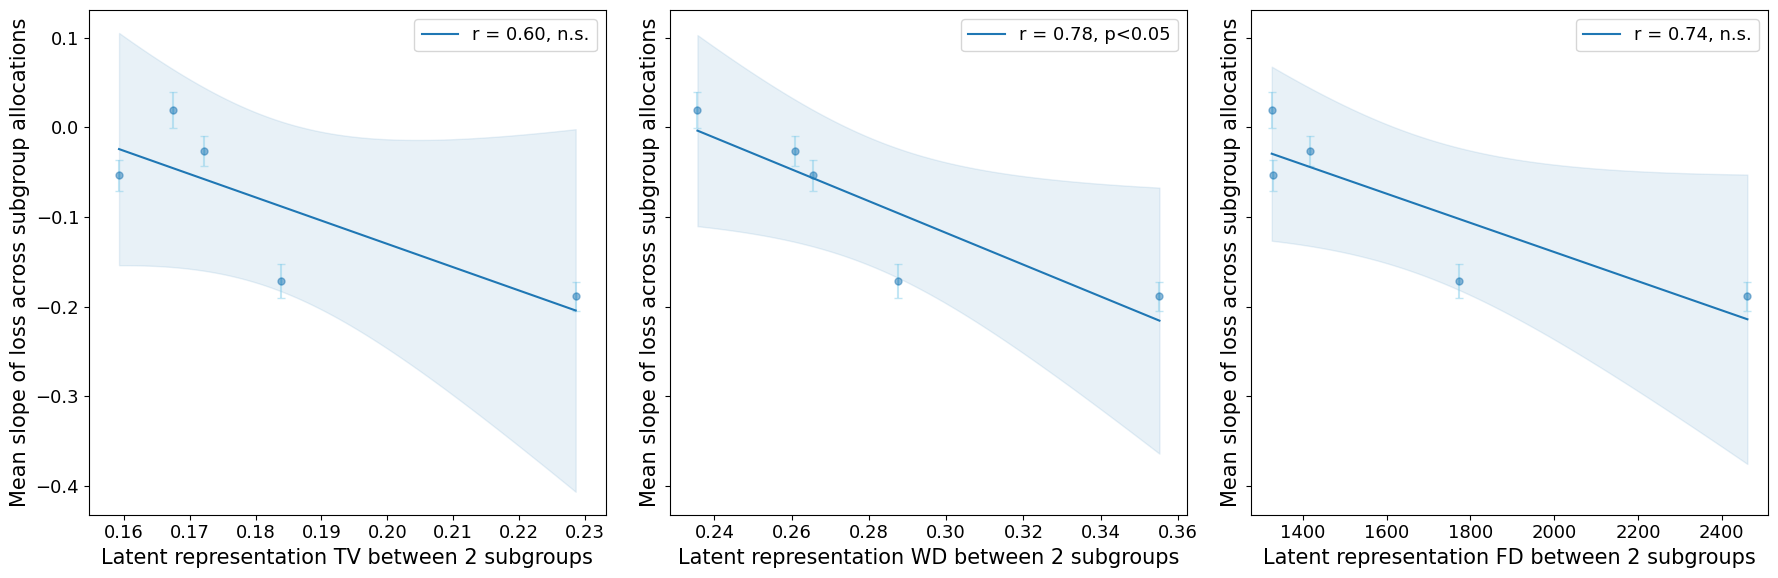

In [20]:
# Paper plot: distance vs slope regression
distance_metrics = ['TV', 'WD', 'FD']
metric = 'loss'

plot_distance_slope(slopes_df2, distance_metrics, metric,
                    save_fig=True,
                    save_path=os.path.join(FIGS_DIR, 'fmmimic2_distances_slope.pdf'))
